In [ ]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')

df_train['Success/Failure'] = np.where(df_train['dd10 CM Content'] >= 70, 1, 0)

In [ ]:
df_train['dd0-dd1 Glucose Gradient'] = (df_train['dd1 Glucose Concentration']- df_train['dd0 Glucose Concentration'])
df_train['dd1-dd3 Glucose Gradient'] = (df_train['dd3 Glucose Concentration']- df_train['dd1 Glucose Concentration'])
df_train['dd3-dd5 Glucose Gradient'] = (df_train['dd5 Glucose Concentration']- df_train['dd3 Glucose Concentration'])
df_train['dd5-dd7 Glucose Gradient'] = (df_train['dd7 Glucose Concentration']- df_train['dd5 Glucose Concentration'])
df_train['dd0-dd1 Lactate Gradient'] = (df_train['dd1 Lactate Concentration']- df_train['dd0 Lactate Concentration'])
df_train['dd1-dd3 Lactate Gradient'] = (df_train['dd3 Lactate Concentration']- df_train['dd1 Lactate Concentration'])
df_train['dd3-dd5 Lactate Gradient'] = (df_train['dd5 Lactate Concentration']- df_train['dd3 Lactate Concentration'])
df_train['dd5-dd7 Lactate Gradient'] = (df_train['dd7 Lactate Concentration']- df_train['dd5 Lactate Concentration'])

In [ ]:
import pandas as pd
import numpy as np

analysis_cols = df_train.columns.tolist()

# 타겟 변수 제외
analysis_cols.remove('Success/Failure')
if 'dd10 CM Content' in analysis_cols:
    analysis_cols.remove('dd10 CM Content')

# 상관관계 계산
correlations = []
for col in analysis_cols:
    subset = df_train[[col, 'Success/Failure']].dropna()
    if len(subset) > 3:
        corr = subset[col].corr(subset['Success/Failure'])
        correlations.append({'Feature': col, 'Correlation': corr})

# 절댓값 기준 내림차순 정렬
corr_df = pd.DataFrame(correlations)
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values(by='Abs_Correlation', ascending=False).drop(columns=['Abs_Correlation'])
corr_df['Correlation'] = corr_df['Correlation'].round(3)

print("성공/실패 상관관계")
print(corr_df.head(20).to_string(index=False))

성공/실패 상관관계
                                        Feature  Correlation
Start Preculture Perfusion [h after inoc] d1-d2       -0.586
                dd0-dd1 Aggregate Size Gradient       -0.461
                        dd2 Average pH Gradient        0.409
           Average DO concentration gradient d0        0.402
                               dd7 Cell Density        0.374
                        dd7 Average pH Gradient        0.366
                               dd1 Cell Density        0.345
                                 dd2 Average pH       -0.343
                  dd2-dd3 Cell Density Gradient       -0.342
                            Preculture Time [h]       -0.337
                        dd3 Average pH Gradient        0.324
                        dd4 Average pH Gradient        0.290
                                 dd7 Average pH        0.285
                  dd3-dd5 Cell Density Gradient        0.277
                          Presence of  IWP2 [h]        0.271
             

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

analysis_cols = df_train.columns.tolist()

# 타겟 변수 제외
analysis_cols.remove('Success/Failure')
if 'dd10 CM Content' in analysis_cols:
    analysis_cols.remove('dd10 CM Content')

ttest_results = []

# Welch's T-test 수행
for col in analysis_cols:
    group1 = df_train[df_train['Success/Failure'] == 1][col].dropna()
    group0 = df_train[df_train['Success/Failure'] == 0][col].dropna()

    t_stat, p_val = stats.ttest_ind(group1, group0, equal_var=False)

    # 점양분 상관계수로 효과 크기 계산
    subset = df_train[[col, 'Success/Failure']].dropna()
    if len(subset) > 3:
        effect_size, _ = stats.pointbiserialr(subset['Success/Failure'], subset[col])
    else:
        effect_size = np.nan

    ttest_results.append({
        'Feature': col,
        'T-statistic': t_stat,
        'P-value': p_val,
        'Effect Size': effect_size
        })

# P-value 기준 정렬 및 필터링
ttest_df = pd.DataFrame(ttest_results).sort_values(by='P-value')
ttest_df['T-statistic'] = ttest_df['T-statistic'].round(3)
ttest_df['P-value'] = ttest_df['P-value'].round(4)
ttest_df['Effect Size'] = ttest_df['Effect Size'].round(3)
ttest_df = ttest_df[ttest_df['P-value'] < 0.05]

print(f"Welch's T-test / P-value 0.05 이하 변수")
print(ttest_df.to_string(index=False))

Welch's T-test / P-value 0.05 이하 변수
                                        Feature  T-statistic  P-value  Effect Size
Start Preculture Perfusion [h after inoc] d1-d2       -3.907   0.0010       -0.586
                               dd7 Cell Density        2.734   0.0093        0.374
                dd0-dd1 Aggregate Size Gradient       -2.873   0.0094       -0.461
           Average DO concentration gradient d0        2.498   0.0202        0.402
                        dd2 Average pH Gradient        2.495   0.0211        0.409
                               dd1 Cell Density        2.285   0.0290        0.345
                                 dd2 Average pH       -2.276   0.0295       -0.343


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

analysis_cols = df_train.columns.tolist()

# 타겟 변수 제외
analysis_cols.remove('Success/Failure')
if 'dd10 CM Content' in analysis_cols:
    analysis_cols.remove('dd10 CM Content')

mwu_results = []

# Mann-Whitney U Test 수행
for col in analysis_cols:
    group1 = df_train[df_train['Success/Failure'] == 1][col].dropna()
    group0 = df_train[df_train['Success/Failure'] == 0][col].dropna()

    stat, p_val = stats.mannwhitneyu(group1, group0, alternative='two-sided')

    # 효과 크기 계산
    n1, n0 = len(group1), len(group0)
    effect_size = -(1 - (2 * stat) / (n1 * n0))

    mwu_results.append({
        'Feature': col,
        'U-statistic': stat,
        'P-value': p_val,
        'Effect Size': effect_size
        })

# P-value 기준 정렬 및 필터링
mwu_df = pd.DataFrame(mwu_results).sort_values(by='P-value')
mwu_df['P-value'] = mwu_df['P-value'].round(4)
mwu_df['Effect Size'] = mwu_df['Effect Size'].round(3)
mwu_df = mwu_df[mwu_df['P-value'] < 0.05]

print("Mann-Whitney U Test / P-value 0.05 이하 변수")
print(mwu_df.to_string(index=False))

Mann-Whitney U Test / P-value 0.05 이하 변수
                                        Feature  U-statistic  P-value  Effect Size
Start Preculture Perfusion [h after inoc] d1-d2         75.5   0.0000       -0.645
                dd0-dd1 Aggregate Size Gradient        100.0   0.0041       -0.529
                DO concentration/cell count dd7        103.0   0.0052       -0.515
           Average DO concentration gradient d0        313.0   0.0104        0.473
                               dd7 Cell Density        312.5   0.0108        0.471
               dd0 DO 2nd derivative/cell count        114.0   0.0120       -0.464
                        dd2 Average pH Gradient        307.0   0.0160        0.445
                          Presence of  IWP2 [h]        294.5   0.0185        0.386
                                 dd2 Average pH        121.0   0.0197       -0.431
                   Average DO concentration dd7        127.0   0.0294       -0.402
               dd0 Average of 2nd derivative D

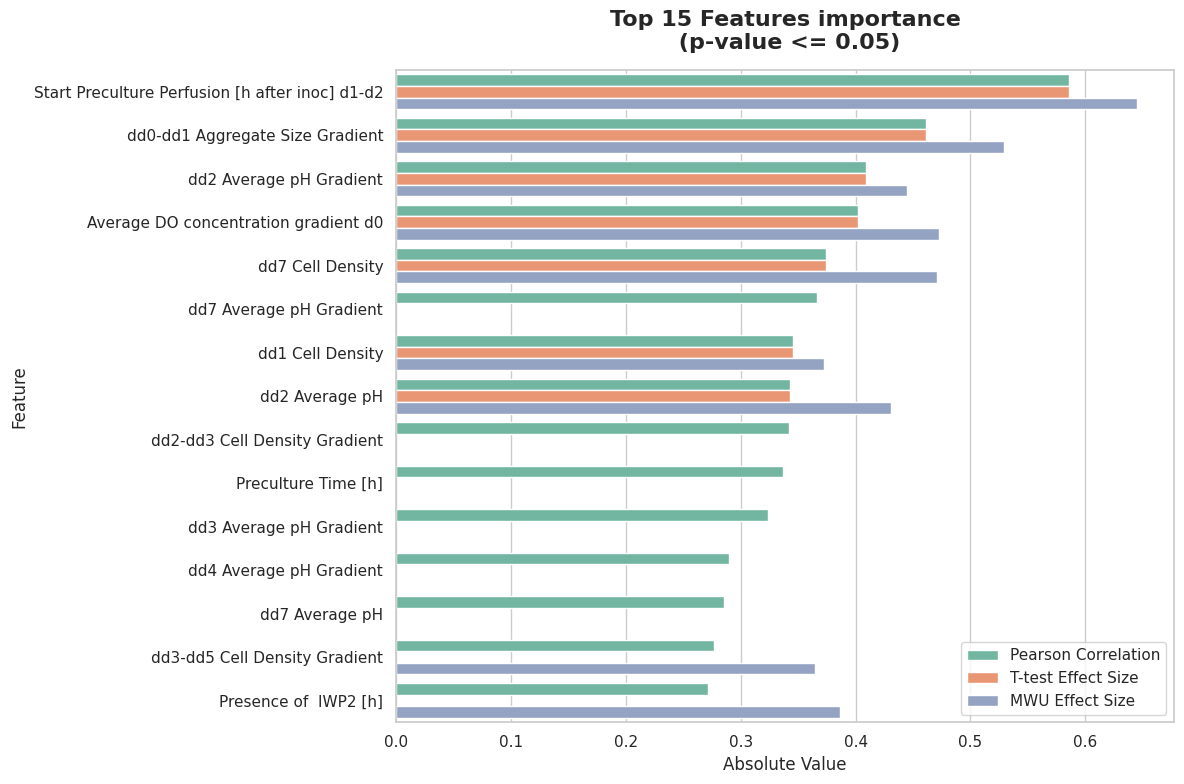

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 세 분석 결과 병합
df_merged = corr_df[['Feature', 'Correlation']].rename(columns={'Correlation': 'Pearson Correlation'})

df_merged = pd.merge(df_merged,
                     ttest_df[['Feature', 'Effect Size']].rename(columns={'Effect Size': 'T-test Effect Size'}),
                     on='Feature', how='outer')

df_merged = pd.merge(df_merged,
                     mwu_df[['Feature', 'Effect Size']].rename(columns={'Effect Size': 'MWU Effect Size'}),
                     on='Feature', how='outer')

# 절댓값 변환 및 상위 변수 추출
df_merged['Pearson Correlation'] = df_merged['Pearson Correlation'].abs()
df_merged['T-test Effect Size'] = df_merged['T-test Effect Size'].abs()
df_merged['MWU Effect Size'] = df_merged['MWU Effect Size'].abs()
df_merged = df_merged.sort_values(by='Pearson Correlation', ascending=False).head(15)

# Wide → Long 변환
melted_df = df_merged.melt(
    id_vars=['Feature'],
    value_vars=['Pearson Correlation', 'T-test Effect Size', 'MWU Effect Size'],
    var_name='Method',
    value_name='Absolute Value'
)

# 시각화
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})

sns.barplot(data=melted_df, y='Feature', x='Absolute Value', hue='Method', palette='Set2')
plt.title('Top 15 Features importance\n (p-value <= 0.05)',
          fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

시계열 컬럼 대상 LMM 결과

               Feature Group  Real Slope Diff/Day  P-value
              Aggregate Size              -4.3802   0.0781
                Cell Density               0.0492   0.0912
DO 2nd derivative/cell count              31.0551   0.1036
Average of 2nd derivative DO              23.3481   0.1101
    Average DO concentration              -0.7620   0.3100
       Lactate Concentration              -0.1465   0.3599
                  Average pH               0.0078   0.4683
 DO concentration/cell count               1.1916   0.5219
       Glucose Concentration              -0.0253   0.8699


/tmp/ipykernel_3687/1198799797.py:127: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_3687/1198799797.py:127: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_3687/1198799797.py:143: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


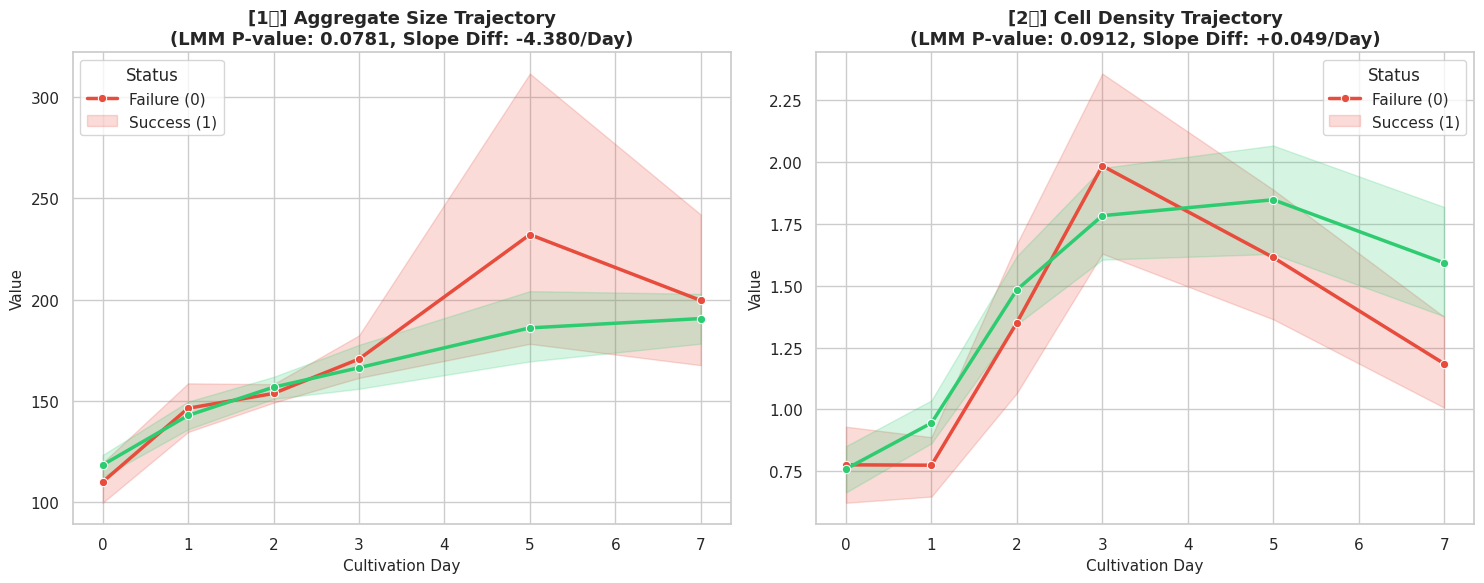

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)

# 데이터 로드 및 전처리
df = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df['Success_Failure'] = np.where(df['dd10 CM Content'] >= 70, 1, 0)
df['Batch_ID'] = df.index

# 시계열 변수 자동 그룹화
ts_dict = {}
for col in df.columns:
    if 'Gradient' in col or 'gradient' in col:
        continue

    match = re.search(r'\bdd(\d+)\b', col)
    if not match:
        match = re.search(r'\bd(\d+)\b', col)

    if match:
        day = int(match.group(1))
        if day > 7: continue

        base_name = col.replace(match.group(0), '').strip()
        base_name = re.sub(' +', ' ', base_name)

        if base_name not in ts_dict:
            ts_dict[base_name] = {}
        ts_dict[base_name][day] = col

valid_features = {k: v for k, v in ts_dict.items() if len(v) >= 3}

# LMM 반복 수행
results = []
melted_data_dict = {}

for base_feature, col_map in valid_features.items():
    days = list(col_map.keys())
    cols = list(col_map.values())

    melted = df.melt(
        id_vars=['Batch_ID', 'Success_Failure'],
        value_vars=cols,
        var_name='Original_Col',
        value_name='Value'
    )
    melted['Day'] = melted['Original_Col'].map({col_map[d]: d for d in days})

    model_data = melted.dropna(subset=['Value', 'Day', 'Success_Failure', 'Batch_ID']).copy()
    melted_data_dict[base_feature] = model_data

    if len(model_data) < 10:
        continue

    try:
        # 스케일링 후 LMM 적합
        val_mean = model_data['Value'].mean()
        val_std = model_data['Value'].std()
        if val_std > 0:
            model_data['Value_Scaled'] = (model_data['Value'] - val_mean) / val_std
        else:
            model_data['Value_Scaled'] = model_data['Value']

        model = smf.mixedlm("Value_Scaled ~ Day * C(Success_Failure)", data=model_data, groups=model_data["Batch_ID"])
        res = model.fit(method='powell')

        # 상호작용 항 추출
        coef = res.params.get('Day:C(Success_Failure)[T.1]', np.nan)
        p_val = res.pvalues.get('Day:C(Success_Failure)[T.1]', np.nan)
        real_coef = coef * val_std if val_std > 0 else coef

        results.append({
            'Feature Group': base_feature,
            'Real Slope Diff/Day': round(real_coef, 4),
            'P-value': round(p_val, 4)
        })
    except Exception as e:
        pass

# 결과 출력
res_df = pd.DataFrame(results).dropna().sort_values(by='P-value')
print("시계열 컬럼 대상 LMM 결과\n")
print(res_df.head(10).to_string(index=False))

# 상위 변수 궤적 시각화
top_2_features = res_df.head(2)['Feature Group'].tolist()

plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
plt.rcParams['font.family'] = 'sans-serif'

for i, feature_name in enumerate(top_2_features):
    plt.subplot(1, 2, i+1)

    plot_data = melted_data_dict[feature_name]

    sns.lineplot(
        data=plot_data, x='Day', y='Value',
        hue='Success_Failure', palette=['#e74c3c', '#2ecc71'],
        marker='o', linewidth=2.5, ci=95
    )

    p_val = res_df[res_df['Feature Group'] == feature_name]['P-value'].values[0]
    slope_diff = res_df[res_df['Feature Group'] == feature_name]['Real Slope Diff/Day'].values[0]

    plt.title(f"[{i+1}위] {feature_name} Trajectory\n(LMM P-value: {p_val:.4f}, Slope Diff: {slope_diff:+.3f}/Day)",
              fontsize=13, fontweight='bold')
    plt.xlabel('Cultivation Day', fontsize=11)
    plt.ylabel('Value', fontsize=11)
    plt.legend(title='Status', labels=['Failure (0)', 'Success (1)'], loc='best')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# 데이터 로드 및 타겟 생성
df = pd.read_csv('train_data_merged.csv', encoding='utf-8')
df['Success_Failure'] = np.where(df['dd10 CM Content'] >= 70, 1, 0)

# 수치형 컬럼 추출 및 타겟 제외
analysis_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Success_Failure', 'dd10 CM Content', 'Batch_ID', 'Success/Failure']:
    if col in analysis_cols:
        analysis_cols.remove(col)

results = []

# 단일변수 로지스틱 회귀 수행 (스케일링 적용)
for col in analysis_cols:
    subset = df[[col, 'Success_Failure']].dropna()

    if len(subset) > 10:
        X = subset[col]
        y = subset['Success_Failure']

        # 표준화 스케일링
        X_scaled = (X - X.mean()) / X.std()
        X_scaled = sm.add_constant(X_scaled)

        try:
            # 로지스틱 모형 적합
            model = sm.Logit(y, X_scaled)
            res = model.fit(disp=0)

            # 통계 지표 추출
            coef = res.params[1]
            p_val = res.pvalues[1]
            odds_ratio = np.exp(coef)

            # 신뢰구간 추출
            conf = res.conf_int()
            ci_lower = np.exp(conf[0][1])
            ci_upper = np.exp(conf[1][1])

            results.append({
                'Feature': col,
                'Odds Ratio': round(odds_ratio, 3),
                'P-value': round(p_val, 4),
                '95% CI': f"[{round(ci_lower, 3)} - {round(ci_upper, 3)}]"
            })
        except Exception as e:
            pass

# 결과 정렬 및 출력
res_df = pd.DataFrame(results).sort_values(by='P-value')

print("■ 단일변수 로지스틱 회귀 분석 결과 (Top 10) ■")
print("* Odds Ratio(오즈비) 해석:")
print("  - 1보다 크면: 수치가 높을수록 성공 확률 증가 긍정적 요인 (+)")
print("  - 1보다 작으면: 수치가 높을수록 성공 확률 감소 (부정적 요인, -)\n")
print(res_df.head(10).to_string(index=False))

■ 단일변수 로지스틱 회귀 분석 결과 (Top 10) ■
* Odds Ratio(오즈비) 해석:
  - 1보다 크면: 수치가 높을수록 성공 확률 증가 긍정적 요인 (+)
  - 1보다 작으면: 수치가 높을수록 성공 확률 감소 (부정적 요인, -)

                                        Feature  Odds Ratio  P-value          95% CI
Start Preculture Perfusion [h after inoc] d1-d2       0.178   0.0042  [0.054 - 0.58]
                dd0-dd1 Aggregate Size Gradient       0.300   0.0111  [0.119 - 0.76]
                        dd2 Average pH Gradient       2.612   0.0202 [1.161 - 5.876]
           Average DO concentration gradient d0       2.812   0.0213 [1.166 - 6.782]
                               dd7 Cell Density       2.628   0.0249  [1.13 - 6.113]
                               dd1 Cell Density       2.230   0.0361 [1.054 - 4.722]
                                 dd2 Average pH       0.373   0.0428 [0.143 - 0.968]
                            Preculture Time [h]       0.477   0.0433 [0.232 - 0.978]
                  dd2-dd3 Cell Density Gradient       0.369   0.0531 [0.135 - 1.013]
           

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# 데이터 로드 및 타겟 생성
df = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df['Success_Failure'] = np.where(df['dd10 CM Content'] >= 70, 1, 0)

# 수치형 컬럼 추출 및 타겟 제외
analysis_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Success_Failure', 'dd10 CM Content', 'Batch_ID', 'Success/Failure']:
    if col in analysis_cols:
        analysis_cols.remove(col)

results = []

# 단일변수 로지스틱 회귀 수행 (스케일링 미적용)
for col in analysis_cols:
    subset = df[[col, 'Success_Failure']].dropna()

    if len(subset) > 10:
        X = subset[col]
        y = subset['Success_Failure']

        X_unscaled = sm.add_constant(X)

        try:
            # 로지스틱 모형 적합
            model = sm.Logit(y, X_unscaled)
            res = model.fit(disp=0)

            # 통계 지표 추출
            coef = res.params[col]
            p_val = res.pvalues[col]
            odds_ratio = np.exp(coef)

            # 신뢰구간 추출
            conf = res.conf_int()
            ci_lower = np.exp(conf.loc[col, 0])
            ci_upper = np.exp(conf.loc[col, 1])

            results.append({
                'Feature': col,
                'Odds Ratio': round(odds_ratio, 2),
                'P-value': round(p_val, 4),
                '95% CI': f"[{round(ci_lower, 4)} - {round(ci_upper, 4)}]"
            })
        except Exception as e:
            pass

# 결과 정렬 및 출력
res_df = pd.DataFrame(results).sort_values(by='P-value')

print("■ 단일변수 로지스틱 회귀 분석 결과 (스케일링 제외, Top 10) ■")
print("* Odds Ratio(오즈비) 해석:")
print("  - 해당 변수가 '1단위(원래 물리적 단위)' 증가할 때 성공 확률이 몇 배가 되는지를 의미합니다.")
print("  - 예: 관류 시작 시간이 1시간 증가할 때 성공 확률 감소폭 등\n")
print(res_df.head(10).to_string(index=False))

■ 단일변수 로지스틱 회귀 분석 결과 (스케일링 제외, Top 10) ■
* Odds Ratio(오즈비) 해석:
  - 해당 변수가 '1단위(원래 물리적 단위)' 증가할 때 성공 확률이 몇 배가 되는지를 의미합니다.
  - 예: 관류 시작 시간이 1시간 증가할 때 성공 확률 감소폭 등

                                        Feature   Odds Ratio  P-value                         95% CI
Start Preculture Perfusion [h after inoc] d1-d2         0.24   0.0042              [0.0888 - 0.6362]
                dd0-dd1 Aggregate Size Gradient         0.00   0.0111                 [0.0 - 0.1726]
                        dd2 Average pH Gradient 385230457.99   0.0202 [21.7655 - 6818249305700968.0]
           Average DO concentration gradient d0         1.01   0.0213              [1.0012 - 1.0152]
                               dd7 Cell Density         5.94   0.0249             [1.2519 - 28.2043]
                               dd1 Cell Density        26.18   0.0361            [1.2365 - 554.4728]
                                 dd2 Average pH         0.02   0.0428              [0.0003 - 0.8749]
                            Pre

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

X = df_train['Start Preculture Perfusion [h after inoc] d1-d2']
y = df_train['Success/Failure']
X_sm = sm.add_constant(X)

# 로지스틱 회귀 수행
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit(disp=0)

p_values = result.pvalues

# 오즈비 및 신뢰구간 계산
odds_ratios = np.exp(result.params)
conf_int = result.conf_int()
conf_int['OR_Lower'] = np.exp(conf_int[0])
conf_int['OR_Upper'] = np.exp(conf_int[1])

# 결과 정리
summary_df = pd.DataFrame({
    'Coefficient': result.params,
    'Effect Size (Odds Ratio)': odds_ratios,
    'p-value': p_values,
    'OR 95% CI Lower': conf_int['OR_Lower'],
    'OR 95% CI Upper': conf_int['OR_Upper']
})

print("\n=== 로지스틱 회귀 분석 결과 (p-value 및 효과 크기) ===")
print(summary_df.drop('const'))


=== 로지스틱 회귀 분석 결과 (p-value 및 효과 크기) ===
                                                 Coefficient  \
Start Preculture Perfusion [h after inoc] d1-d2    -1.436644   

                                                 Effect Size (Odds Ratio)  \
Start Preculture Perfusion [h after inoc] d1-d2                  0.237724   

                                                 p-value  OR 95% CI Lower  \
Start Preculture Perfusion [h after inoc] d1-d2  0.00423         0.088832   

                                                 OR 95% CI Upper  
Start Preculture Perfusion [h after inoc] d1-d2         0.636174  
